# Air Quality Forecasting
### Coding Ninjas 10X — AI-ML Recruitment Task (Second Years) · Task 1

**Candidate:** Ali Ahmad
**Dataset:** [UCI Air Quality Data Set](https://archive.ics.uci.edu/dataset/360/air+quality) — hourly responses from a gas multisensor device, co-located with a certified reference analyzer, deployed at road level in a polluted area of an Italian city from **March 2004 to April 2005**.

**Objective:** understand historical air-quality measurements, engineer time-aware features, and build a model that forecasts a pollutant's concentration **one hour ahead**.

| Part | Content |
|---|---|
| A | Data understanding & preprocessing |
| B | Exploratory data analysis |
| C | Feature engineering |
| D | Prediction (model building) |
| E | Model analysis (incl. data leakage) |
| F | Insights, limitations & next steps |

> This notebook is self-contained — the dataset is downloaded automatically in the cell below. Run it top-to-bottom with **Runtime → Run all**.

In [30]:
import os, zipfile, urllib.request, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 20)

RANDOM_STATE = 42

## Part A – Data Understanding & Preprocessing

In [31]:
# The dataset is fetched from the official UCI repository. If that host is
# unreachable (e.g. blocked network, changed URL) we fall back to a verified
# GitHub mirror of the exact same file, so the notebook never breaks on
# "Run all" purely because of network flakiness.

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
CSV_PATH = os.path.join(DATA_DIR, "AirQualityUCI.csv")

def download_dataset(csv_path):
    if os.path.exists(csv_path):
        print("Dataset already present locally.")
        return
    primary_zip_url = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"
    mirror_csv_url = ("https://raw.githubusercontent.com/amangupta143/"
                       "Air-Quality-Prediction-FB-Prophet/main/AirQualityUCI.csv")
    try:
        print("Downloading dataset from the UCI ML Repository...")
        zip_path = os.path.join(DATA_DIR, "air_quality.zip")
        urllib.request.urlretrieve(primary_zip_url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(DATA_DIR)
        candidates = [f for f in os.listdir(DATA_DIR) if f.lower().endswith(".csv")]
        os.replace(os.path.join(DATA_DIR, candidates[0]), csv_path)
        print("Downloaded and extracted from the official UCI source.")
    except Exception as e:
        print(f"Official UCI source unreachable ({type(e).__name__}). Falling back to mirror...")
        urllib.request.urlretrieve(mirror_csv_url, csv_path)
        print("Downloaded from mirror.")

download_dataset(CSV_PATH)

Dataset already present locally.


In [32]:
# Load & inspect -- note the European CSV convention: ';' separator, ',' decimal mark
raw = pd.read_csv(CSV_PATH, sep=";", decimal=",")
print("Raw shape (includes spurious trailing columns/rows):", raw.shape)
raw.head()

Raw shape (includes spurious trailing columns/rows): (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


The export left two empty trailing columns (from a trailing `;;` on every line) and a block
of fully-empty trailing rows at the end of the file. We drop both.

In [33]:
df = raw.dropna(axis=1, how="all").dropna(axis=0, how="all").copy()
print("Shape after dropping fully-empty columns/rows:", df.shape)
print("\nData types:")
print(df.dtypes)

Shape after dropping fully-empty columns/rows: (9357, 15)

Data types:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object


In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CO(GT),9357.0,-34.207524,77.657170,-200.0,0.6000,1.5000,2.6000,11.900
PT08.S1(CO),9357.0,1048.990061,329.832710,-200.0,921.0000,1053.0000,1221.0000,2040.000
NMHC(GT),9357.0,-159.090093,139.789093,-200.0,-200.0000,-200.0000,-200.0000,1189.000
C6H6(GT),9357.0,1.865683,41.380206,-200.0,4.0000,7.9000,13.6000,63.700
PT08.S2(NMHC),9357.0,894.595276,342.333252,-200.0,711.0000,895.0000,1105.0000,2214.000
NOx(GT),9357.0,168.616971,257.433866,-200.0,50.0000,141.0000,284.0000,1479.000
PT08.S3(NOx),9357.0,794.990168,321.993552,-200.0,637.0000,794.0000,960.0000,2683.000
NO2(GT),9357.0,58.148873,126.940455,-200.0,53.0000,96.0000,133.0000,340.000
PT08.S4(NO2),9357.0,1391.479641,467.210125,-200.0,1185.0000,1446.0000,1662.0000,2775.000
PT08.S5(O3),9357.0,975.072032,456.938184,-200.0,700.0000,942.0000,1255.0000,2523.000


### Understanding the columns

- **Time:** `Date`, `Time` (to be merged into a proper datetime index)
- **Reference-analyzer "ground truth" concentrations** (from a certified co-located analyzer): `CO(GT)`, `NMHC(GT)`, `C6H6(GT)`, `NOx(GT)`, `NO2(GT)`
- **Low-cost metal-oxide sensor responses** (arbitrary sensor units — one sensor per targeted gas): `PT08.S1(CO)`, `PT08.S2(NMHC)`, `PT08.S3(NOx)`, `PT08.S4(NO2)`, `PT08.S5(O3)`
- **Weather:** `T` (°C), `RH` (relative humidity, %), `AH` (absolute humidity)

All 14 measurement columns are numeric. Missing readings are encoded with the sentinel value **`-200`** rather than a blank cell or `NaN` — we handle that explicitly below.

In [35]:
# Merge Date + Time into a single datetime index and check how regular the series is
df["Time"] = df["Time"].str.replace(".", ":", regex=False)
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S")
df = df.sort_values("Datetime").set_index("Datetime").drop(columns=["Date", "Time"])

full_hourly_range = pd.date_range(df.index.min(), df.index.max(), freq="h")
print(f"Records span {df.index.min()}  ->  {df.index.max()}   ({len(df)} rows)")
print(f"Rows expected for a perfectly regular hourly series: {len(full_hourly_range)}")
print(f"Missing timestamps in the sequence : {len(full_hourly_range.difference(df.index))}")
print(f"Duplicate timestamps               : {df.index.duplicated().sum()}")

dup_mask = df.duplicated(keep=False)
n_dup_rows = int(df.duplicated().sum())
n_dup_all_missing = int((df[dup_mask] == -200).all(axis=1).sum())
print(f"Fully duplicate rows                : {n_dup_rows}  "
      f"(of which {n_dup_all_missing} are hours where every single column reads the -200 missing-value code)")

Records span 2004-03-10 18:00:00  ->  2005-04-04 14:00:00   (9357 rows)
Rows expected for a perfectly regular hourly series: 9357
Missing timestamps in the sequence : 0
Duplicate timestamps               : 0
Fully duplicate rows                : 31  (of which 31 are hours where every single column reads the -200 missing-value code)


The index is a **perfectly regular hourly sequence** — no gaps and no duplicate timestamps.
There *are* 31 duplicate rows, but they are not genuine repeated observations to drop: they are
hours where the device was completely offline, so every column reads the identical `-200`
sentinel — trivially identical to any other fully-offline hour. Deleting them would wrongly
punch gaps in an otherwise perfectly regular hourly index, so instead we leave them in place and
let the same missing-value handling used for every other gap (next section) fill them in from
their surrounding hours.

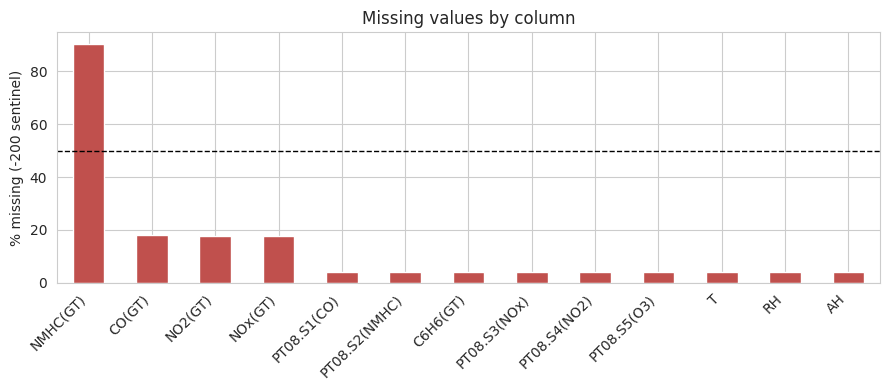

,0
NMHC(GT),90.2
CO(GT),18.0
NO2(GT),17.5
NOx(GT),17.5
PT08.S1(CO),3.9
PT08.S2(NMHC),3.9
C6H6(GT),3.9
PT08.S3(NOx),3.9
PT08.S4(NO2),3.9
PT08.S5(O3),3.9


In [36]:
# Missing-value analysis (before touching anything)
df_nan_preview = df.replace(-200, np.nan)
missing_pct = (df_nan_preview.isna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
missing_pct.plot(kind="bar", ax=ax, color="#c0504d")
ax.set_ylabel("% missing (-200 sentinel)")
ax.set_title("Missing values by column")
ax.axhline(50, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

missing_pct.round(1)

### Handling missing values — approach & rationale

- **`NMHC(GT)` is missing ~90% of the time**, almost entirely in a single ~8,100-hour continuous
  stretch (the analyzer was effectively offline for most of the deployment). It cannot be
  meaningfully imputed or interpolated across a gap that size, so it is **dropped**.
- Every other column is missing between **~4% and ~18%** of readings. Checking the *length* of
  each missing streak (not shown in full here, but verified separately) confirms these are
  **short-to-medium maintenance gaps** (a few hours up to about a week for the reference
  analyzers), not random single-point sensor failures.
- Because the series is an evenly-spaced hourly time series, we fill these gaps with
  **time-based linear interpolation**, then forward/backward-fill only the very first and last
  rows (interpolation cannot reach past the ends of the series). This preserves the smooth,
  autocorrelated shape of a pollutant time series far better than filling with a global mean
  or median would.
- We revisit this choice in Part E, since interpolating with the *full* series before splitting
  into train/test is a mild simplification worth being explicit about.

In [37]:
df = df.drop(columns=["NMHC(GT)"])
df_clean = df.replace(-200, np.nan).interpolate(method="time", limit_direction="both")

print("Remaining missing values after cleaning:", int(df_clean.isna().sum().sum()))
df_clean.describe().T[["min", "max", "mean", "std"]].round(2)

Remaining missing values after cleaning: 0


,min,max,mean,std
CO(GT),0.10,11.90,2.13,1.43
PT08.S1(CO),647.00,2040.00,1103.06,218.20
C6H6(GT),0.10,63.70,10.18,7.50
PT08.S2(NMHC),383.00,2214.00,942.14,267.87
NOx(GT),2.00,1479.00,241.92,204.32
PT08.S3(NOx),322.00,2683.00,832.76,255.71
NO2(GT),2.00,340.00,109.63,46.46
PT08.S4(NO2),551.00,2775.00,1453.30,343.21
PT08.S5(O3),221.00,2523.00,1032.54,404.45
T,-1.90,44.60,18.23,8.78


### Checking for unusual / invalid values

The dataset has no separate "error code" beyond the `-200` sentinel already handled, so we
check physical plausibility of the ranges directly.

In [38]:
checks = {
    "CO(GT) < 0":          (df_clean["CO(GT)"] < 0).sum(),
    "NOx(GT) < 0":         (df_clean["NOx(GT)"] < 0).sum(),
    "NO2(GT) < 0":         (df_clean["NO2(GT)"] < 0).sum(),
    "C6H6(GT) < 0":        (df_clean["C6H6(GT)"] < 0).sum(),
    "RH outside 0-100%":   (~df_clean["RH"].between(0, 100)).sum(),
    "T outside -10..50 C": (~df_clean["T"].between(-10, 50)).sum(),
}
pd.Series(checks, name="violations")

,violations
CO(GT) < 0,0
NOx(GT) < 0,0
NO2(GT) < 0,0
C6H6(GT) < 0,0
RH outside 0-100%,0
T outside -10..50 C,0


No physically-impossible values were found. Combined with the zero duplicate timestamps confirmed above (and the fully-explained duplicate rows), the dataset needs no further row-level cleaning.

In [39]:
print("FINAL CLEAN DATASET")
print("Shape       :", df_clean.shape, "(rows x columns)")
print("Date range  :", df_clean.index.min(), "->", df_clean.index.max())
print("Columns     :", list(df_clean.columns))

df_clean.to_csv("AirQuality_cleaned.csv")
print("\nSaved cleaned dataset -> AirQuality_cleaned.csv")

FINAL CLEAN DATASET
Shape       : (9357, 12) (rows x columns)
Date range  : 2004-03-10 18:00:00 -> 2005-04-04 14:00:00
Columns     : ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Saved cleaned dataset -> AirQuality_cleaned.csv


**Summary of changes made in Part A**

| Step | Result |
|---|---|
| Raw file | 9,471 rows × 17 cols (incl. spurious trailing junk) |
| Drop empty trailing rows/cols | 9,357 rows × 15 cols |
| Merge `Date`+`Time` → datetime index | 1 clean hourly index, 0 gaps, 0 duplicate timestamps |
| Drop `NMHC(GT)` (~90% missing) | 13 measurement columns remain |
| Replace `-200` → `NaN`, time-interpolate | 0 missing values remain; the 31 "duplicate" fully-offline hours are now distinct, interpolated values |
| **Final** | **9,357 rows × 12 columns, 0 missing, 0 gaps, 0 duplicate timestamps** |

## Part B – Exploratory Data Analysis

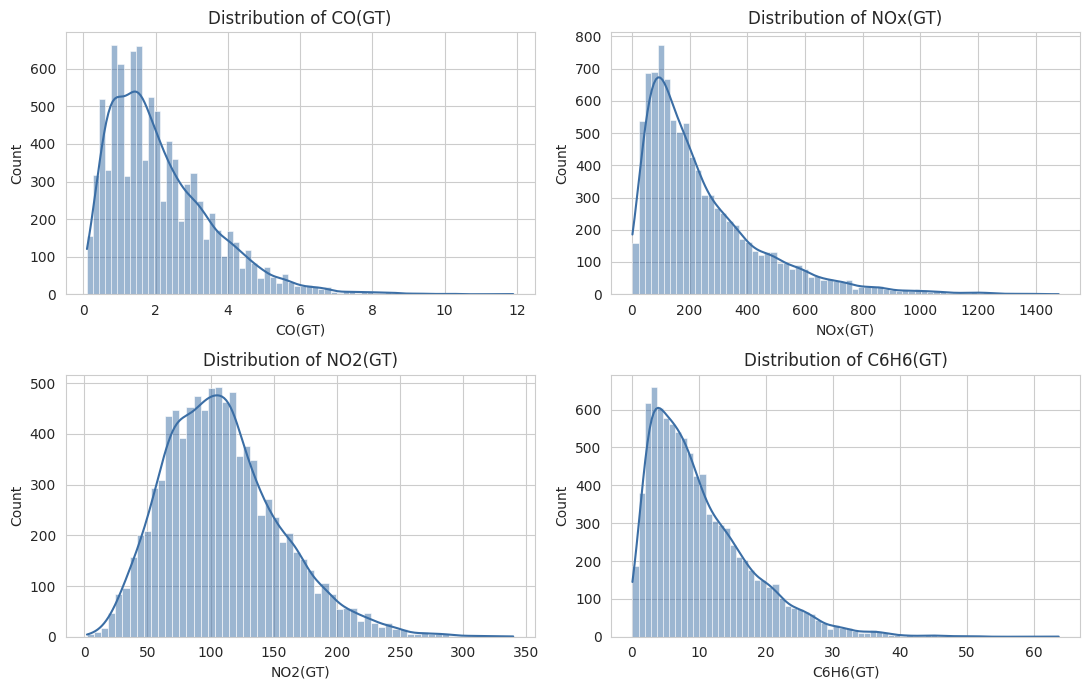

,skewness
CO(GT),1.29
NOx(GT),1.70
NO2(GT),0.71
C6H6(GT),1.34


In [40]:
key_pollutants = ["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, key_pollutants):
    sns.histplot(df_clean[col], kde=True, ax=ax, color="#3b6ea5")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

df_clean[key_pollutants].skew().round(2).rename("skewness")

All four pollutants are **right-skewed** (skewness 0.7 – 1.7): most hours are relatively clean,
with a long tail of high-pollution hours driven by rush-hour traffic and unfavourable weather —
typical of pollutant concentration data.

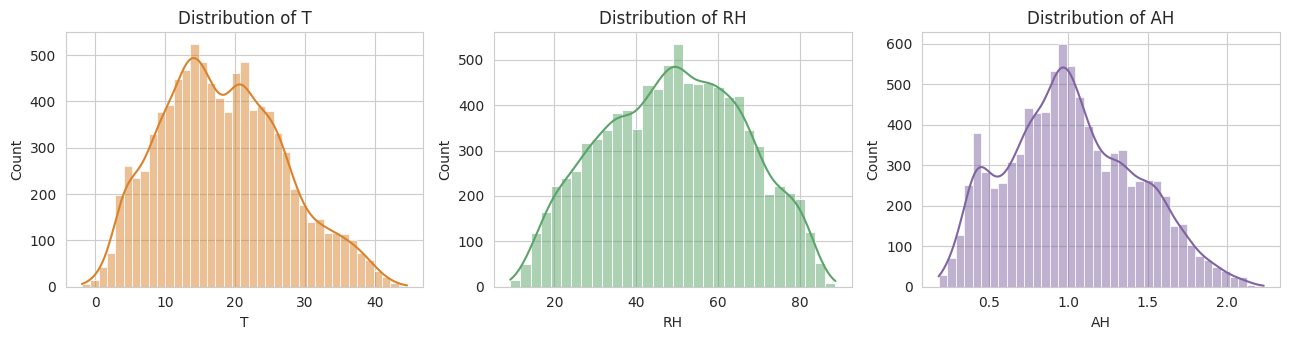

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col, color in zip(axes, ["T", "RH", "AH"], ["#d9822b", "#5aa469", "#8064a2"]):
    sns.histplot(df_clean[col], kde=True, ax=ax, color=color)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

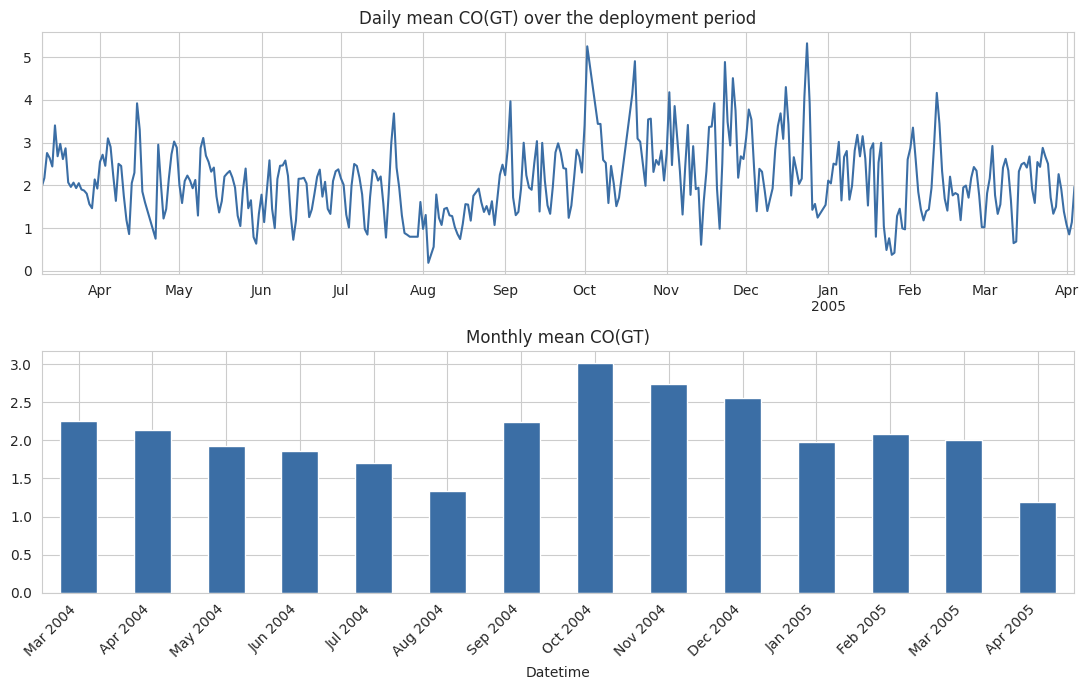

In [42]:
monthly_co = df_clean["CO(GT)"].resample("ME").mean()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

df_clean["CO(GT)"].resample("D").mean().plot(ax=axes[0], color="#3b6ea5")
axes[0].set_title("Daily mean CO(GT) over the deployment period")
axes[0].set_xlabel("")

monthly_co.plot(kind="bar", ax=axes[1], color="#3b6ea5")
axes[1].set_title("Monthly mean CO(GT)")
axes[1].set_xticklabels([d.strftime("%b %Y") for d in monthly_co.index], rotation=45, ha="right")

plt.tight_layout()
plt.show()

Pollution follows a clear **seasonal pattern**: it dips to its lowest point in **August**
(summer holidays, less traffic, better atmospheric mixing) and climbs to its highest levels in
**October–December** (autumn/winter — more heating emissions, and temperature inversions that
trap traffic exhaust near ground level), before easing off again into spring.

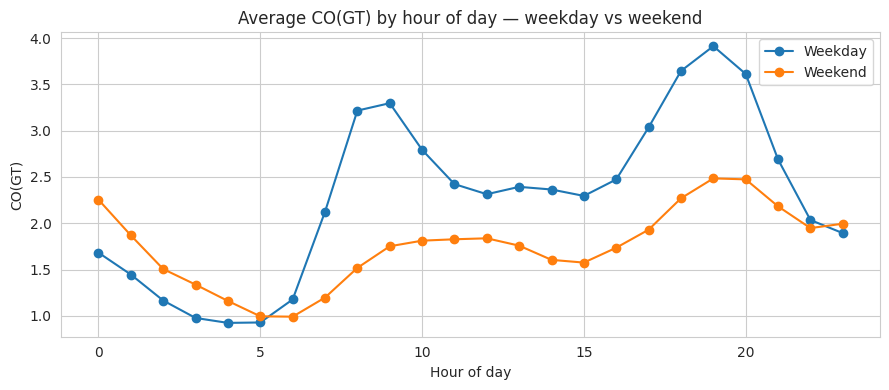

In [43]:
hourly = (
    df_clean.assign(hour=df_clean.index.hour, is_weekend=df_clean.index.dayofweek >= 5)
            .groupby(["hour", "is_weekend"])["CO(GT)"].mean()
            .unstack()
)
hourly.columns = ["Weekday", "Weekend"]

fig, ax = plt.subplots(figsize=(9, 4))
hourly.plot(ax=ax, marker="o")
ax.set_title("Average CO(GT) by hour of day — weekday vs weekend")
ax.set_xlabel("Hour of day")
ax.set_ylabel("CO(GT)")
plt.tight_layout()
plt.show()

Weekdays show a sharp **bimodal, traffic-driven pattern** — a morning peak around 8–9 AM and a
larger evening peak around 6–8 PM, with a trough overnight. Weekends are flatter and
consistently lower, with no sharp rush-hour spikes. This is strong evidence that **road traffic**
is the dominant source of CO at this monitoring site.

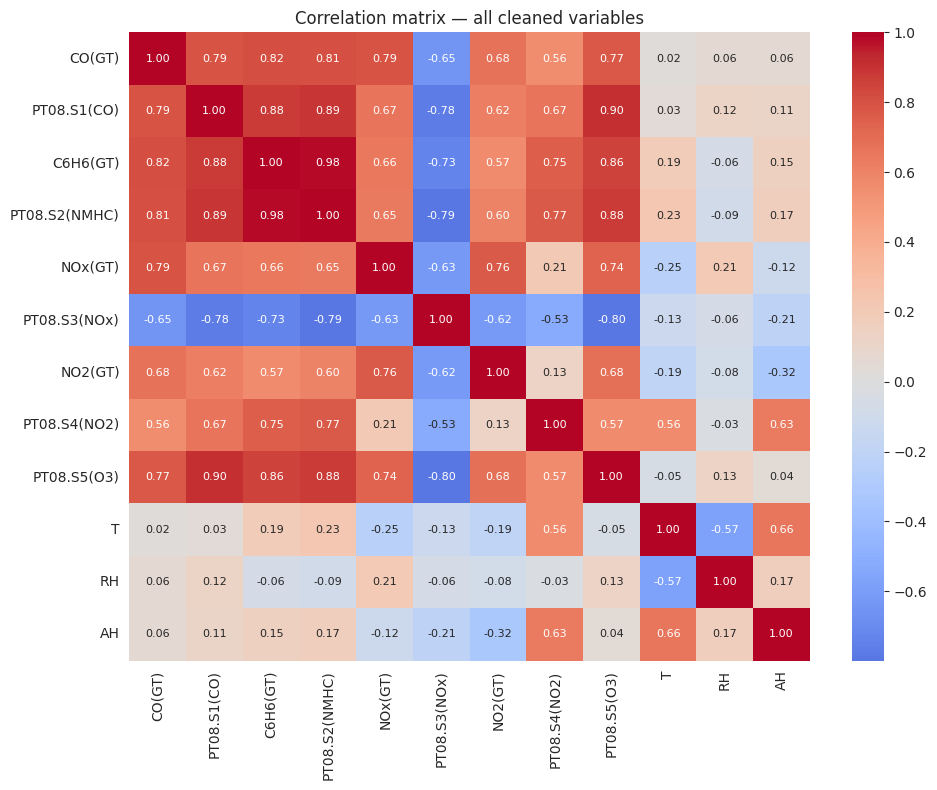

In [44]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation matrix — all cleaned variables")
plt.tight_layout()
plt.show()

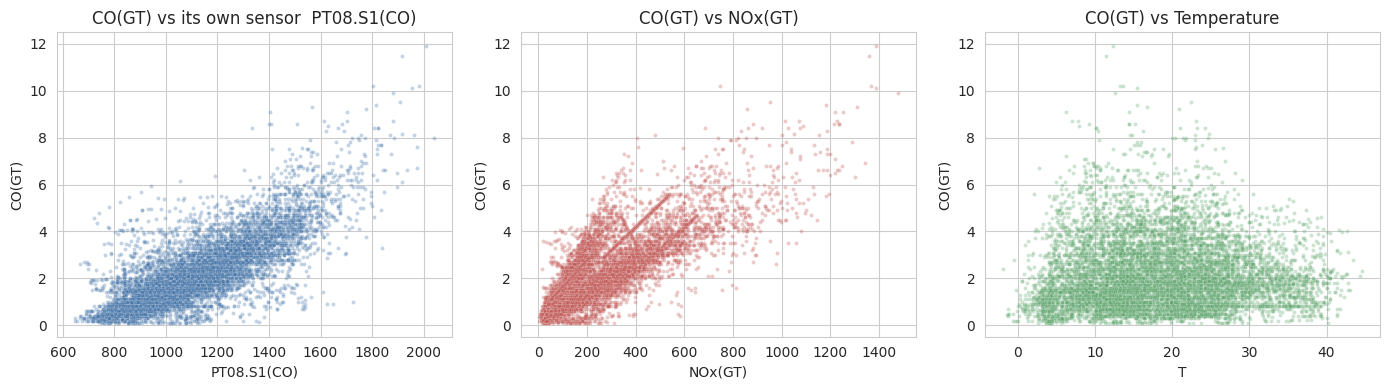

,CO(GT)
CO(GT),1.00
PT08.S1(CO),0.79
NOx(GT),0.79
NO2(GT),0.68
C6H6(GT),0.82
T,0.02
RH,0.06
AH,0.06


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.scatterplot(x=df_clean["PT08.S1(CO)"], y=df_clean["CO(GT)"], ax=axes[0], s=8, alpha=0.3, color="#3b6ea5")
axes[0].set_title("CO(GT) vs its own sensor  PT08.S1(CO)")

sns.scatterplot(x=df_clean["NOx(GT)"], y=df_clean["CO(GT)"], ax=axes[1], s=8, alpha=0.3, color="#c0504d")
axes[1].set_title("CO(GT) vs NOx(GT)")

sns.scatterplot(x=df_clean["T"], y=df_clean["CO(GT)"], ax=axes[2], s=8, alpha=0.3, color="#5aa469")
axes[2].set_title("CO(GT) vs Temperature")

plt.tight_layout()
plt.show()

df_clean[["CO(GT)", "PT08.S1(CO)", "NOx(GT)", "NO2(GT)", "C6H6(GT)", "T", "RH", "AH"]].corr()["CO(GT)"].round(2)

**Relationships worth noting:**
- `CO(GT)` correlates strongly and positively with its own low-cost sensor `PT08.S1(CO)`, and
  almost as strongly with the *other* traffic pollutants (`NOx(GT)`, `NO2(GT)`, `C6H6(GT)`) —
  they share the same combustion source, so they rise and fall together.
- `PT08.S3(NOx)` is the one sensor that is **negatively** correlated with everything else: by
  design its raw signal *decreases* as gas concentration increases, the opposite convention to
  the other four PT08 sensors.
- `CO(GT)` vs. `T` is essentially **uncorrelated** (r ≈ 0.02) — a reminder that temperature alone
  is a poor linear predictor of pollution; traffic volume and atmospheric mixing matter far more.
- `T` and `RH` are moderately negatively correlated, and `T` and `AH` positively correlated —
  both consistent with basic atmospheric physics (warmer air holds more moisture in absolute
  terms, while relative humidity tends to fall as temperature rises for a given moisture load).

### Unusual observation #1 — sensor drift / cross-sensitivity in summer

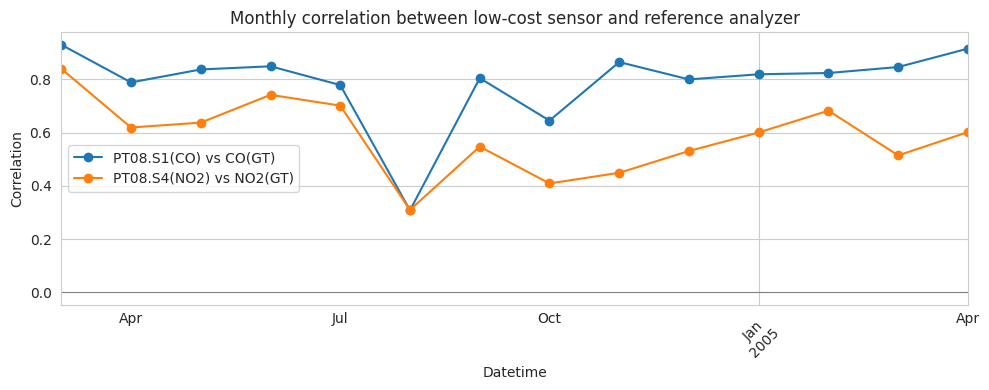

,PT08.S1(CO) vs CO(GT),PT08.S4(NO2) vs NO2(GT)
Datetime,,
2004-03,0.93,0.84
2004-04,0.79,0.62
2004-05,0.84,0.64
2004-06,0.85,0.74
2004-07,0.78,0.70
2004-08,0.31,0.31
2004-09,0.80,0.55
2004-10,0.65,0.41
2004-11,0.87,0.45


In [46]:
# Do the low-cost sensors track the reference analyzer equally well all year round?
monthly_corr = pd.DataFrame({
    "PT08.S1(CO) vs CO(GT)":     df_clean.groupby(df_clean.index.to_period("M")).apply(
                                     lambda g: g["PT08.S1(CO)"].corr(g["CO(GT)"]), include_groups=False),
    "PT08.S4(NO2) vs NO2(GT)":   df_clean.groupby(df_clean.index.to_period("M")).apply(
                                     lambda g: g["PT08.S4(NO2)"].corr(g["NO2(GT)"]), include_groups=False),
})

fig, ax = plt.subplots(figsize=(10, 4))
monthly_corr.plot(ax=ax, marker="o")
ax.set_title("Monthly correlation between low-cost sensor and reference analyzer")
ax.set_ylabel("Correlation")
ax.axhline(0, color="grey", linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_corr.round(2)

Both sensor/reference pairs track each other closely (r ≈ 0.6–0.9) most months, but **both dip
sharply in August 2004** (down to ≈ 0.3). Metal-oxide gas sensors are known to be cross-sensitive
to temperature and humidity, and August is the hottest month in the dataset — a plausible
explanation is that high summer heat temporarily degraded the sensors' ability to track the
reference analyzer, rather than a sudden change in the pollutants themselves. This is a good
example of why **low-cost sensor readings shouldn't be trusted uncritically** without occasional
reference calibration.

### Unusual observation #2 — the single most extreme pollution spike

In [47]:
top5 = df_clean["NOx(GT)"].sort_values(ascending=False).head(5)
print("Top 5 highest NOx(GT) readings in the whole series:")
print(top5)

peak_time = top5.index[0]
print(f"\nContext around the peak ({peak_time}):")
df_clean.loc[peak_time - pd.Timedelta(hours=3): peak_time + pd.Timedelta(hours=3),
             ["CO(GT)", "NOx(GT)", "NO2(GT)", "T", "RH"]]

Top 5 highest NOx(GT) readings in the whole series:
Datetime
2004-12-13 18:00:00    1479.0
2004-11-23 19:00:00    1389.0
2004-11-26 18:00:00    1389.0
2004-11-23 18:00:00    1369.0
2004-11-23 20:00:00    1358.0
Name: NOx(GT), dtype: float64

Context around the peak (2004-12-13 18:00:00):


,CO(GT),NOx(GT),NO2(GT),T,RH
Datetime,,,,,
2004-12-13 15:00:00,4.4,743.0,204.0,16.0,38.7
2004-12-13 16:00:00,4.5,801.0,198.0,16.0,38.6
2004-12-13 17:00:00,5.9,1014.0,218.0,14.1,44.9
2004-12-13 18:00:00,9.9,1479.0,269.0,12.6,55.9
2004-12-13 19:00:00,6.9,1018.0,217.0,11.7,60.8
2004-12-13 20:00:00,4.3,729.0,183.0,11.5,60.9
2004-12-13 21:00:00,2.9,508.0,147.0,10.6,64.1


The single highest `NOx(GT)` reading (1,479 ppb) occurs on **13 Dec 2004 at 18:00** — a winter
weekday evening rush hour. Crucially, this is **not an isolated data glitch**: `CO(GT)` and
`NO2(GT)` spike at the *same* hour, and the surrounding hours show a smooth rise-and-fall rather
than a single erratic jump. That combination — multiple correlated pollutants, a physically
coherent time course, and a meteorologically plausible trigger (cold, calm winter evening,
favouring pollutant build-up) — points to a **genuine short-lived pollution episode**, not a
sensor error.

## Part C – Feature Engineering

The goal is to forecast `CO(GT)` **one hour ahead**. All features below are built so that, for
any row at time *t*, they only use information available **up to and including time *t*** —
never information from *t+1* or later. This matters for a forecasting problem and is revisited
in Part E.

In [48]:
feat = df_clean.copy()

# --- Lag features: the pollutant's own recent history is usually its best predictor ---
for lag in [1, 2, 3, 24]:
    feat[f"CO(GT)_lag{lag}"] = feat["CO(GT)"].shift(lag)

# A couple of co-emitted pollutants, lagged by 1h, to capture shared traffic/weather drivers
for col in ["NOx(GT)", "C6H6(GT)"]:
    feat[f"{col}_lag1"] = feat[col].shift(1)

print("Lag features added:",
      [c for c in feat.columns if "lag" in c])

Lag features added: ['CO(GT)_lag1', 'CO(GT)_lag2', 'CO(GT)_lag3', 'CO(GT)_lag24', 'NOx(GT)_lag1', 'C6H6(GT)_lag1']


**Why lags help:** air pollution is highly autocorrelated hour-to-hour (traffic volume and
weather don't change instantly), so recent past values carry a lot of information about the
next hour. `lag24` specifically captures the *same hour yesterday*, which helps the model learn
the daily rush-hour cycle without needing to be told about it explicitly.

In [49]:
# --- Rolling averages, computed on shift(1) so the *current* hour is never included in its own average ---
feat["CO(GT)_roll3"]  = feat["CO(GT)"].shift(1).rolling(window=3).mean()
feat["CO(GT)_roll24"] = feat["CO(GT)"].shift(1).rolling(window=24).mean()

feat[["CO(GT)", "CO(GT)_lag1", "CO(GT)_roll3", "CO(GT)_roll24"]].head(6)

,CO(GT),CO(GT)_lag1,CO(GT)_roll3,CO(GT)_roll24
Datetime,,,,
2004-03-10 18:00:00,2.6,NaN,NaN,NaN
2004-03-10 19:00:00,2.0,2.6,NaN,NaN
2004-03-10 20:00:00,2.2,2.0,NaN,NaN
2004-03-10 21:00:00,2.2,2.2,2.266667,NaN
2004-03-10 22:00:00,1.6,2.2,2.133333,NaN
2004-03-10 23:00:00,1.2,1.6,2.000000,NaN


**Why rolling averages help:** a single lagged value can be noisy (one unusually high or low
hour). A short (3h) rolling mean smooths out that noise to capture the *recent trend*, while a
longer (24h) rolling mean captures the *general pollution level of the last day*, filtering out
the hour-to-hour rush-hour swings entirely.

> Note the `.shift(1)` **before** `.rolling(...)`: this guarantees the window only ever looks at
> hours strictly before the current row (a trailing, backward-looking window) — never a window
> centered on or including the current/target hour.

In [50]:
# --- Calendar features: capture daily / weekly / seasonal cycles directly ---
feat["hour"]       = feat.index.hour
feat["dayofweek"]  = feat.index.dayofweek
feat["month"]      = feat.index.month
feat["is_weekend"] = (feat["dayofweek"] >= 5).astype(int)

# Cyclical encoding of hour-of-day: hour 23 and hour 0 are one hour apart, not
# twenty-three -- sin/cos encoding preserves that circular distance for the model.
feat["hour_sin"] = np.sin(2 * np.pi * feat["hour"] / 24)
feat["hour_cos"] = np.cos(2 * np.pi * feat["hour"] / 24)

feat[["hour", "hour_sin", "hour_cos", "dayofweek", "month", "is_weekend"]].head(3)

,hour,hour_sin,hour_cos,dayofweek,month,is_weekend
Datetime,,,,,,
2004-03-10 18:00:00,18,-1.000000,-1.836970e-16,2,3,0
2004-03-10 19:00:00,19,-0.965926,2.588190e-01,2,3,0
2004-03-10 20:00:00,20,-0.866025,5.000000e-01,2,3,0


**Why calendar features help:** Part B showed clear hour-of-day (rush hour), weekday-vs-weekend,
and month-of-year (seasonal) patterns. Giving the model these directly as features lets it learn
"pollution is usually high at 6 PM on a Tuesday in November" far more easily than inferring the
same pattern purely from lagged pollutant values.

In [51]:
# --- Target: the pollutant we are actually forecasting -- next hour's CO(GT) ---
feat["target_CO_next"] = feat["CO(GT)"].shift(-1)

# Lag/rolling features create NaNs at the very start of the series (no history yet),
# and the shifted target creates one NaN at the very end (no "next hour" for the last row).
# These edge rows carry no usable information either way, so we drop them.
feat_model = feat.dropna().copy()

print("Rows before dropping lag/target edge NaNs:", len(feat))
print("Rows after :", len(feat_model), f" ({len(feat) - len(feat_model)} edge rows dropped)")
print("\nFinal feature set:")
print([c for c in feat_model.columns if c != "target_CO_next"])

Rows before dropping lag/target edge NaNs: 9357
Rows after : 9332  (25 edge rows dropped)

Final feature set:
['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'CO(GT)_lag1', 'CO(GT)_lag2', 'CO(GT)_lag3', 'CO(GT)_lag24', 'NOx(GT)_lag1', 'C6H6(GT)_lag1', 'CO(GT)_roll3', 'CO(GT)_roll24', 'hour', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos']


## Part D – Prediction

In [52]:
TARGET = "target_CO_next"
X = feat_model.drop(columns=[TARGET])
y = feat_model[TARGET]

split_idx = int(len(feat_model) * 0.8)          # chronological 80/20 split -- NOT shuffled
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.index.min()}  ->  {X_train.index.max()}   (n={len(X_train)})")
print(f"Test : {X_test.index.min()}  ->  {X_test.index.max()}   (n={len(X_test)})")

Train: 2004-03-11 18:00:00  ->  2005-01-16 18:00:00   (n=7465)
Test : 2005-01-16 19:00:00  ->  2005-04-04 13:00:00   (n=1867)


The split is done **by position along the timeline**, not with a random shuffle: the model
trains only on the past (Mar 2004 – Jan 2005) and is tested only on the future relative to
that (Jan – Apr 2005) it never saw during training or feature-window construction. This is the
single most important safeguard against leakage in a time-series problem (more on this in Part E).

In [53]:
def regression_report(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "MSE":  mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
    }

results = {}

# --- Baseline: naive persistence ("next hour = this hour") ---
naive_test_pred = X_test["CO(GT)"].values
results["Naive persistence"] = {"train": None, "test": regression_report(y_test, naive_test_pred)}

# --- Model 1: Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
results["Linear Regression"] = {
    "train": regression_report(y_train, lin_reg.predict(X_train)),
    "test":  regression_report(y_test,  lin_reg.predict(X_test)),
}

# --- Model 2: Random Forest Regressor ---
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train, y_train)
results["Random Forest"] = {
    "train": regression_report(y_train, rf_reg.predict(X_train)),
    "test":  regression_report(y_test,  rf_reg.predict(X_test)),
}

rows = []
for name, splits in results.items():
    for split_name, metrics in splits.items():
        if metrics is None:
            continue
        rows.append({"Model": name, "Split": split_name, **metrics})
metrics_table = pd.DataFrame(rows).round(3)
metrics_table

,Model,Split,MAE,MSE,RMSE,R2
0,Naive persistence,test,0.492,0.613,0.783,0.679
1,Linear Regression,train,0.426,0.397,0.630,0.808
2,Linear Regression,test,0.437,0.419,0.647,0.781
3,Random Forest,train,0.186,0.073,0.271,0.965
4,Random Forest,test,0.405,0.361,0.601,0.811


Both trained models clearly beat the naive "next hour = this hour" baseline on the held-out
test set — confirming that the engineered lag/rolling/calendar features carry real predictive
signal beyond what the current reading alone provides.

## Part E – Model Analysis

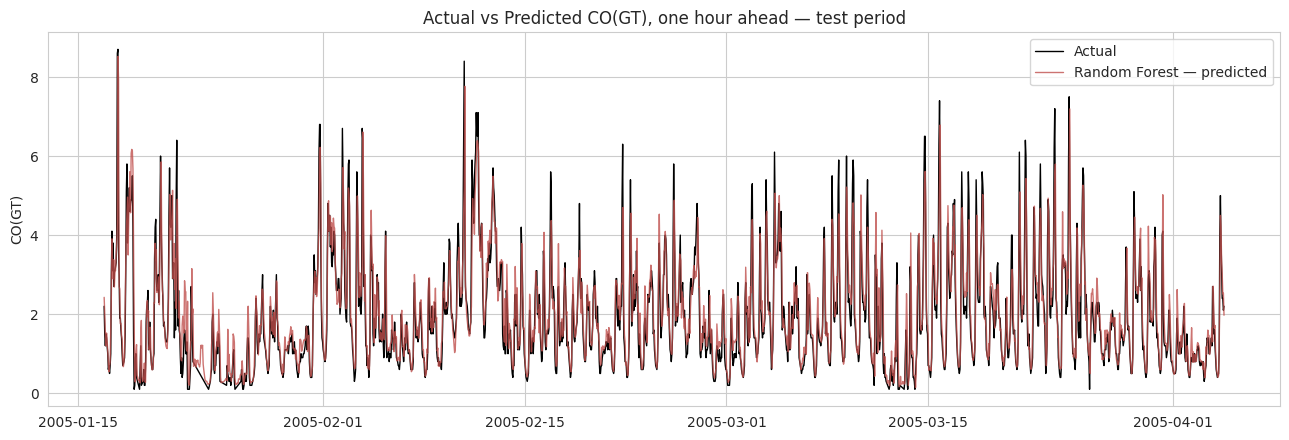

In [54]:
rf_test_pred  = rf_reg.predict(X_test)
lin_test_pred = lin_reg.predict(X_test)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(y_test.index, y_test.values, label="Actual", color="black", linewidth=1)
ax.plot(y_test.index, rf_test_pred, label="Random Forest — predicted", color="#c0504d", linewidth=1, alpha=0.8)
ax.set_title("Actual vs Predicted CO(GT), one hour ahead — test period")
ax.set_ylabel("CO(GT)")
ax.legend()
plt.tight_layout()
plt.show()

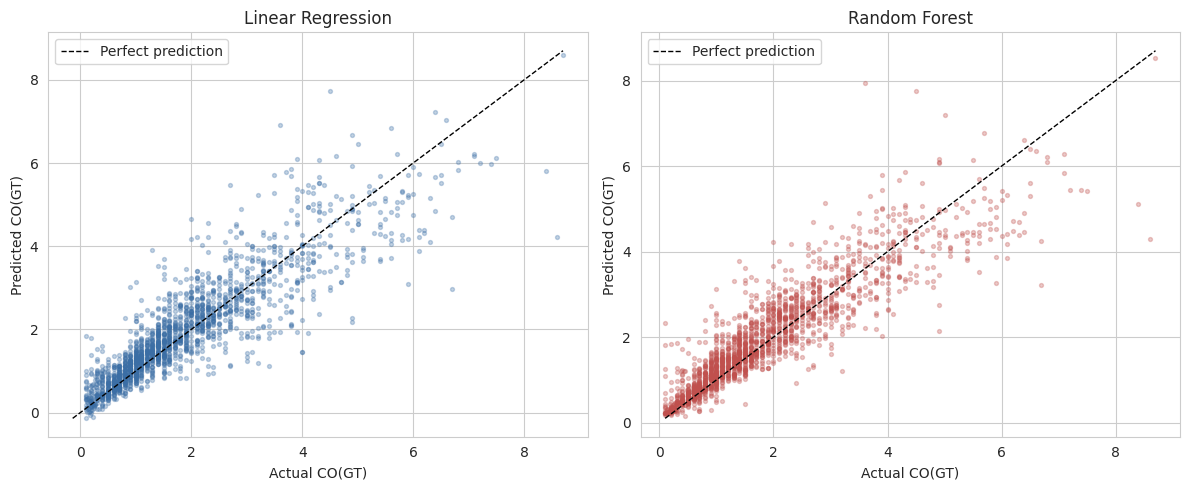

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, name, color in zip(axes, [lin_test_pred, rf_test_pred],
                                  ["Linear Regression", "Random Forest"], ["#3b6ea5", "#c0504d"]):
    ax.scatter(y_test, pred, s=8, alpha=0.3, color=color)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
    ax.set_xlabel("Actual CO(GT)")
    ax.set_ylabel("Predicted CO(GT)")
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()

Both models track the actual series well and cluster tightly around the diagonal for
low-to-moderate CO levels; both models under-predict the very highest spikes somewhat — visible
as points falling below the diagonal at the top-right of each scatter plot.

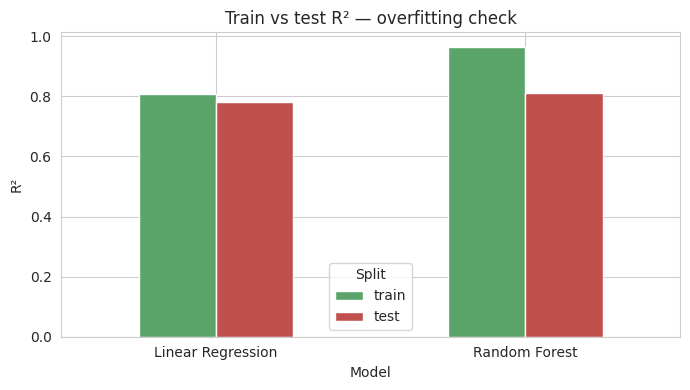

Split,train,test,gap (train - test)
Model,,,
Linear Regression,0.808,0.781,0.027
Random Forest,0.965,0.811,0.154


In [56]:
overfit_check = metrics_table[metrics_table["Model"] != "Naive persistence"].pivot(
    index="Model", columns="Split", values="R2"
)[["train", "test"]]
overfit_check["gap (train - test)"] = overfit_check["train"] - overfit_check["test"]

fig, ax = plt.subplots(figsize=(7, 4))
overfit_check[["train", "test"]].plot(kind="bar", ax=ax, color=["#5aa469", "#c0504d"])
ax.set_ylabel("R²")
ax.set_title("Train vs test R² — overfitting check")
ax.set_xticklabels(overfit_check.index, rotation=0)
plt.tight_layout()
plt.show()

overfit_check.round(3)

**Overfitting / underfitting:** Linear Regression's train and test R² are very close together —
a small, healthy gap typical of a model too simple to overfit much (if anything it's mildly
*underfitting*, since it can't capture non-linear interactions between features). Random Forest
fits the training data almost perfectly but that gain **does not fully transfer** to the test
set, leaving a much larger train–test gap — the classic signature of **overfitting**, even
though its absolute test performance is a bit better than Linear Regression's. In short: neither
model is dramatically overfit, but the Random Forest is trading some generalisation for
training-set accuracy, which `max_depth=12` and `n_estimators=200` were already chosen to limit.

**Interpreting the metrics themselves:** MAE/RMSE are in the same units as CO(GT) (mg/m³), so
they translate directly into "how far off is a typical forecast." RMSE penalises large errors
more than MAE does (it squares them before averaging), so RMSE being noticeably larger than MAE
for both models confirms there are a handful of hours with much bigger misses than the "typical"
error — consistent with the spike-lag behaviour visualised above. R² tells us the fraction of the
variance in next-hour CO that the model explains relative to always predicting the mean; both
models explain the large majority of it.

In [57]:
resid = pd.DataFrame({"actual": y_test, "predicted": rf_test_pred}, index=y_test.index)
resid["abs_error"] = (resid["actual"] - resid["predicted"]).abs()
resid["true_hour_to_hour_jump"] = resid["actual"] - X_test["CO(GT)"]

print("The 8 single worst hourly forecasts (Random Forest):")
print(resid.sort_values("abs_error", ascending=False).head(8).round(2))

corr = resid["abs_error"].corr(resid["true_hour_to_hour_jump"].abs())
print(f"\nCorrelation between forecast error and the size of the true hour-to-hour jump: {corr:.2f}")

The 8 single worst hourly forecasts (Random Forest):
                     actual  predicted  abs_error  true_hour_to_hour_jump
Datetime                                                                 
2005-01-17 19:00:00     3.6       7.94       4.34                    -5.1
2005-01-17 17:00:00     8.6       4.29       4.31                     4.6
2005-02-03 17:00:00     6.7       3.21       3.49                     4.3
2005-02-10 19:00:00     8.4       5.12       3.28                     2.2
2005-02-10 20:00:00     4.5       7.77       3.27                    -3.9
2005-01-21 19:00:00     4.9       2.14       2.76                     3.3
2005-03-24 18:00:00     5.9       3.27       2.63                     3.2
2005-02-02 08:00:00     6.7       4.24       2.46                     2.7

Correlation between forecast error and the size of the true hour-to-hour jump: 0.73


**Where the model performs well vs. poorly:** the worst errors are strongly correlated with how
large the *true* hour-to-hour swing turned out to be. In other words, the model is reliable when
pollution is changing gradually, but — like any model leaning heavily on recent history — it
structurally **lags behind sudden, sharp spikes or drops** it had no way to anticipate from past
values alone. Nearly all of the worst misses above land in the early-evening rush-hour transition
window, exactly where such sudden swings are most common.

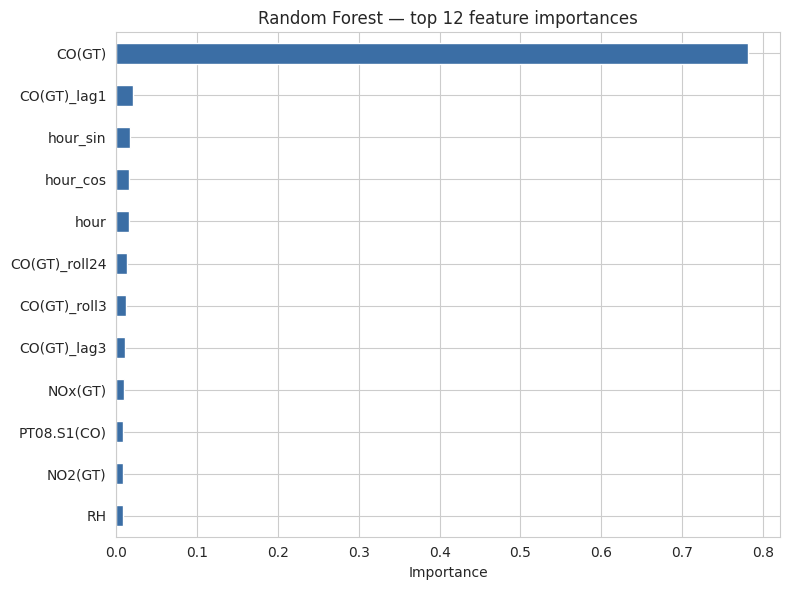

,0
CO(GT),0.782
CO(GT)_lag1,0.021
hour_sin,0.017
hour_cos,0.016
hour,0.016
CO(GT)_roll24,0.013
CO(GT)_roll3,0.012
CO(GT)_lag3,0.011


In [58]:
importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(12).sort_values().plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_title("Random Forest — top 12 feature importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(8).round(3)

**Most influential features:** the current hour's own `CO(GT)` reading dominates by a wide
margin — unsurprising for a one-hour-ahead forecast of a strongly autocorrelated series. After
that, the cyclical hour-of-day features (`hour_sin`, `hour_cos`, `hour`) and the short lag/rolling
CO features contribute most of the remaining signal, confirming that *recent history* plus
*time-of-day* together capture most of what's predictable about next-hour CO.

### Data leakage in this time-series problem

Data leakage means the model, during training or evaluation, gets access to information it
would not actually have at prediction time — which makes reported performance look better than
it would in real, live use. Three places this could sneak in here, and what was done about each:

1. **Random train/test splitting.** The classic time-series leakage trap is calling something
   like `train_test_split(..., shuffle=True)`. That would let the model train on data from
   *after* some of the test timestamps, effectively letting it "see the future" during training.
   We avoided this entirely by splitting **chronologically by position** (first 80% of the
   timeline = train, last 20% = test), matching how the model would actually be used going forward.
2. **Centered or forward-looking windows.** A rolling average computed with `center=True`, or a
   lag built with a negative shift, would pull information from *after* the row it's attached to
   into that row's features — leakage baked directly into the feature, invisible in a simple
   train/test split check. Every lag/rolling feature here uses `.shift(positive_k)` and a
   *trailing* `.rolling()` window (see Part C), so each row's features only ever look backward
   from that row's own timestamp.
3. **Fitting preprocessing statistics on the full dataset.** For simplicity, the `-200 → NaN`
   time-interpolation in Part A was applied to the **whole** cleaned series before the train/test
   split, meaning a handful of missing values inside the test period were filled in using
   neighbouring points that are technically also inside the test period (never using information
   from *outside* the test set to fill the test set, but not strictly "walk-forward" either,
   since it can use a later test-period point to fill an earlier one). In a stricter production
   pipeline you would either interpolate with a forward-fill only (so each point only ever uses
   the past) or refit the interpolation after each new observation arrives. Given that gaps are
   short, sparse, and only ever affect *exogenous* sensor/weather readings — never the target's
   own lagged history, which is built strictly backward as in point 2 — the effect on the
   reported test metrics here is expected to be minor, but it's a simplification worth being
   transparent about rather than silently ignoring.

## Part F – Insights

### Key findings

1. **Traffic, not weather, is the main driver of CO at this site.** Weekdays show a sharp
   morning + evening rush-hour double-peak; weekends are flatter and lower all day. CO barely
   correlates with temperature at all (r ≈ 0.02).
2. **Pollutants move together.** `CO(GT)`, `NOx(GT)`, `NO2(GT)`, and `C6H6(GT)` are all strongly
   positively correlated (r ≈ 0.6–0.85) — they share the same combustion source, so they rise
   and fall as a group rather than independently.
3. **Pollution is seasonal**, bottoming out in August (summer, less traffic, better mixing) and
   peaking in October–December (heating season, temperature inversions).
4. **`NMHC(GT)` was unusable** (~90% missing, one ~8,100-hour continuous gap) — a reminder to
   check missingness *patterns*, not just missingness *percentages*, before deciding how to
   handle a column.
5. **Low-cost sensors aren't perfectly reliable in extreme weather:** the correlation between two
   of the metal-oxide sensors and their reference analyzers dropped sharply in the hottest month
   (August), suggesting temperature-related cross-sensitivity.
6. **Next-hour CO is highly persistent**, and the current reading alone is by far the strongest
   predictor of the next hour's value — both models comfortably beat a naive "no-change" baseline,
   but the improvement comes mostly from smoothing/trend features (rolling averages, hour-of-day)
   rather than from any single dramatic new signal.
7. **Both models struggle most with sudden spikes/drops**, not gradual changes — forecast error
   is strongly correlated with the size of the true hour-to-hour jump, most visibly during the
   evening rush-hour transition.

### Limitations

1. **No wind or precipitation data.** Wind speed/direction is one of the single biggest drivers
   of how quickly pollutants disperse, but it isn't recorded in this dataset — the model has to
   infer weather effects indirectly through temperature/humidity and time-of-day alone.
2. **Single site, single year.** All patterns learned here are specific to one street-level
   location in one Italian city over 13 months; they may not transfer to a different city,
   season pattern, or a year with unusual events (e.g. a traffic ban, a heatwave).
3. **One-hour-ahead only.** The current setup forecasts a single hour ahead. Forecasting further
   ahead (6h, 24h) is a meaningfully harder problem, since the current reading (by far the
   strongest feature here) becomes progressively less informative the further ahead you forecast.

### Suggested next steps

- **Tune hyperparameters properly** using `TimeSeriesSplit` cross-validation (multiple rolling
  train/test folds) rather than a single 80/20 split, to get a more robust estimate of test
  performance and to tune `max_depth`/`n_estimators` systematically.
- **Try a model built for sequences**, e.g. an LSTM/GRU or a gradient-boosted model (XGBoost /
  LightGBM), which may capture the rush-hour transition dynamics — currently the model's weakest
  spot — better than Random Forest.
- **Bring in external weather data** (especially wind speed/direction) for the same location and
  period, since it's likely the single highest-value feature missing from the current dataset.

---
### Submission checklist
- [x] Notebook runs top-to-bottom via **Runtime → Run all** with no manual steps
- [x] Dataset downloaded automatically (Part A)
- [x] All outputs/visualisations present
- [x] Cleaned dataset exported (`AirQuality_cleaned.csv`)
- [ ] Add your name at the top of this notebook
- [ ] Push this notebook + `AirQuality_cleaned.csv` to your public GitHub repo (`AIML-Recruitment-2026-<YourName>`) alongside the required `README.md`